# Matplotlib Part 2 — Advanced Visualization

This notebook continues the Matplotlib learning series and focuses on advanced visualization techniques for **Data Science, Scientific Computing, Bioinformatics, and Cancer AI**.

## Learning goals

By the end of this notebook, you should be able to:

- Build complex multi-panel figures
- Use advanced legends, annotations, colors, and colorbars
- Visualize statistical distributions and uncertainty
- Create heatmaps, contour plots, and 3D plots
- Visualize images and segmentation masks
- Create publication-quality scientific figures
- Combine Matplotlib with NumPy and Pandas
- Build visualizations for clinical, molecular, survival, and medical-imaging data

> **Part 2 assumes that you already know the basic plotting concepts covered in Part 1.**

# 1. Imports and Global Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm

np.random.seed(42)

# 2. Figure and Axes — Deeper Understanding

A **Figure** is the complete canvas, while an **Axes** is an individual plotting area.

Advanced Matplotlib becomes much easier once this hierarchy is clear.

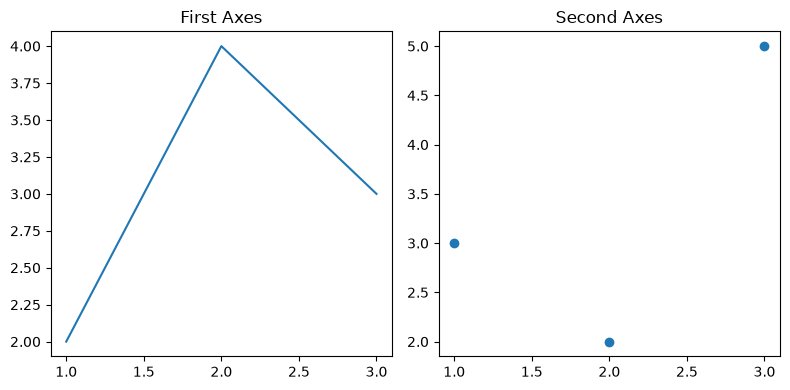

In [2]:
fig = plt.figure(figsize=(8, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot([1, 2, 3], [2, 4, 3])
ax1.set_title("First Axes")

ax2.scatter([1, 2, 3], [3, 2, 5])
ax2.set_title("Second Axes")

plt.tight_layout()
plt.show()

## Creating an Axes at an Exact Position

`fig.add_axes()` accepts `[left, bottom, width, height]` as fractions of the Figure.

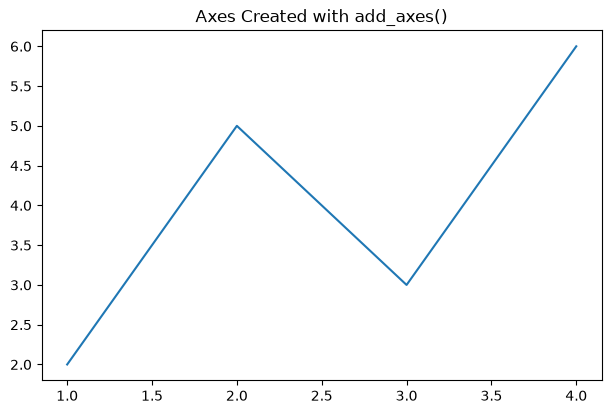

In [3]:
fig = plt.figure(figsize=(8, 5))

ax = fig.add_axes([0.15, 0.15, 0.7, 0.7])

ax.plot([1, 2, 3, 4], [2, 5, 3, 6])
ax.set_title("Axes Created with add_axes()")

plt.show()

# 3. GridSpec

`GridSpec` is useful when panels need different sizes.

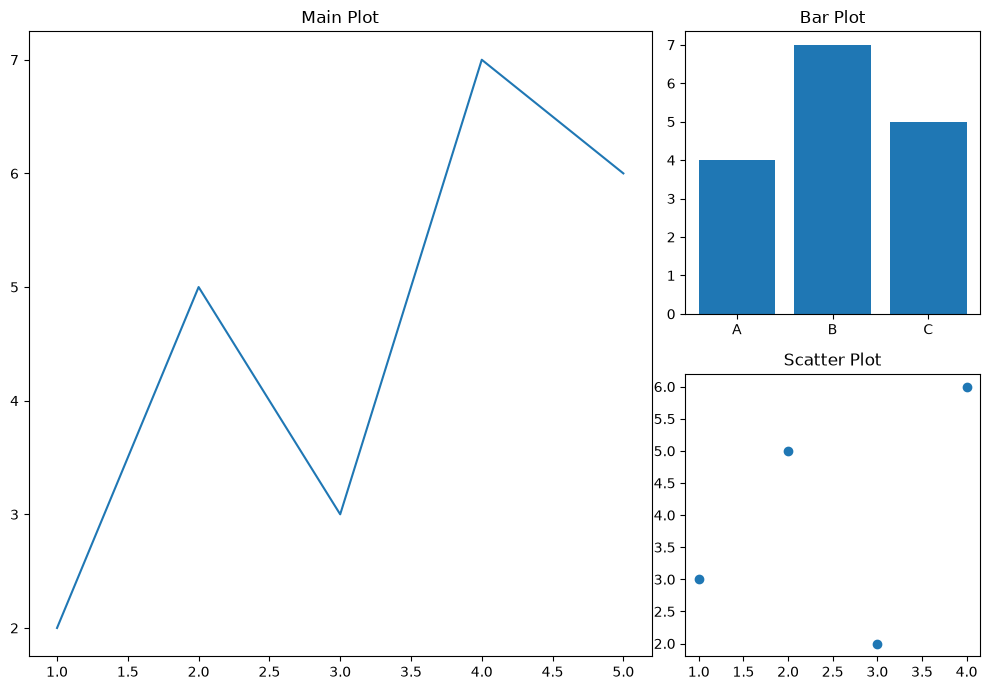

In [4]:
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 3, figure=fig)

ax_main = fig.add_subplot(gs[:, :2])
ax_top = fig.add_subplot(gs[0, 2])
ax_bottom = fig.add_subplot(gs[1, 2])

ax_main.plot([1, 2, 3, 4, 5], [2, 5, 3, 7, 6])
ax_main.set_title("Main Plot")

ax_top.bar(["A", "B", "C"], [4, 7, 5])
ax_top.set_title("Bar Plot")

ax_bottom.scatter([1, 2, 3, 4], [3, 5, 2, 6])
ax_bottom.set_title("Scatter Plot")

plt.tight_layout()
plt.show()

## GridSpec Ratios

`width_ratios` and `height_ratios` control relative panel sizes.

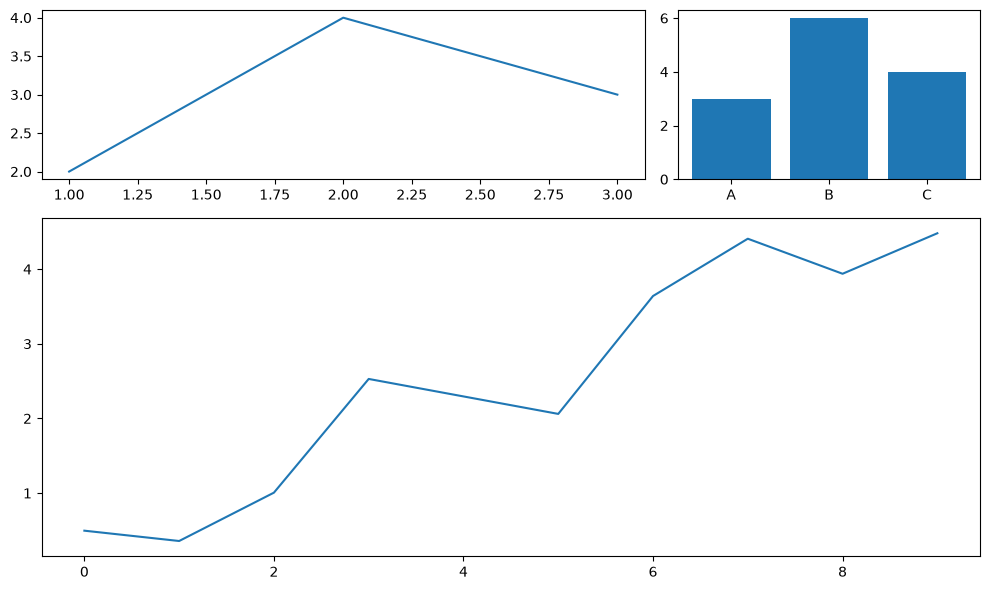

In [5]:
fig = plt.figure(figsize=(10, 6))

gs = GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[2, 1],
    height_ratios=[1, 2]
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

ax1.plot([1, 2, 3], [2, 4, 3])
ax2.bar(["A", "B", "C"], [3, 6, 4])
ax3.plot(np.arange(10), np.random.randn(10).cumsum())

plt.tight_layout()
plt.show()

# 4. Twin Axes

Twin axes allow variables with different scales to share one plot.

Use them carefully because two scales can sometimes make a figure harder to interpret.

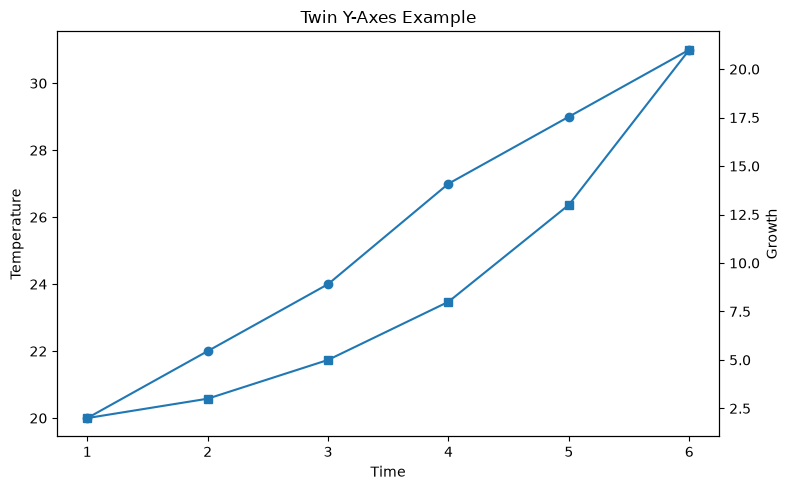

In [6]:
time_points = np.arange(1, 7)
temperature_values = [20, 22, 24, 27, 29, 31]
growth_values = [2, 3, 5, 8, 13, 21]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(time_points, temperature_values, marker="o", label="Temperature")
ax2.plot(time_points, growth_values, marker="s", label="Growth")

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature")
ax2.set_ylabel("Growth")

plt.title("Twin Y-Axes Example")
plt.tight_layout()
plt.show()

# 5. Advanced Legends

Useful parameters include:

- `loc`
- `bbox_to_anchor`
- `ncol`
- `frameon`
- `fontsize`
- `title`

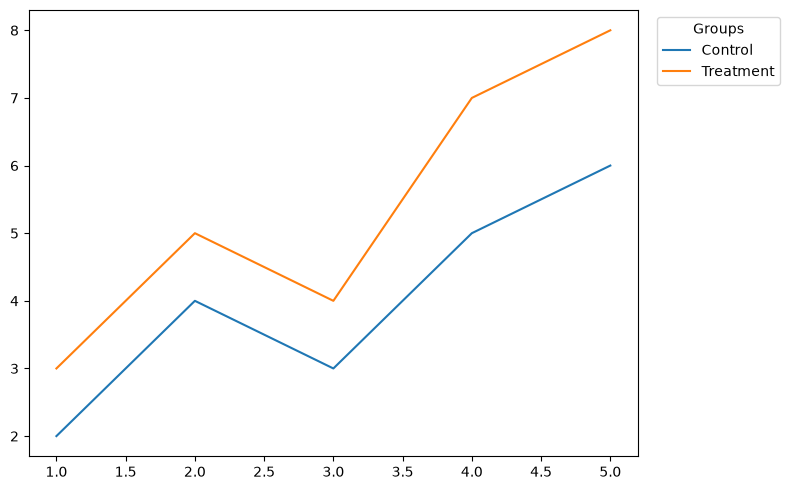

In [7]:
plot_x = np.arange(1, 6)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(plot_x, [2, 4, 3, 5, 6], label="Control")
ax.plot(plot_x, [3, 5, 4, 7, 8], label="Treatment")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    title="Groups"
)

plt.tight_layout()
plt.show()

## Custom Legend Handles

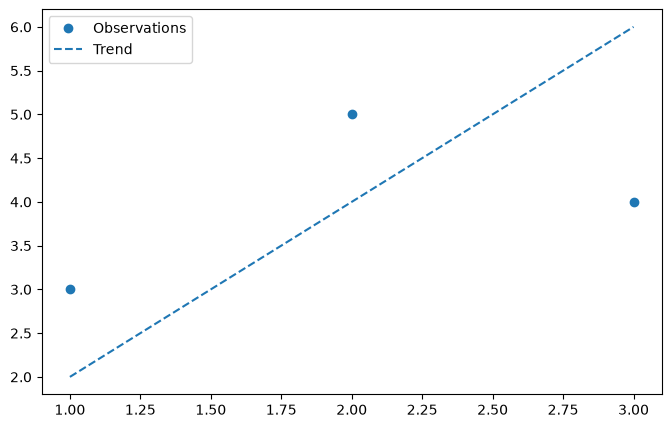

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter([1, 2, 3], [3, 5, 4])
ax.plot([1, 2, 3], [2, 4, 6], linestyle="--")

handles = [
    Line2D([0], [0], marker="o", linestyle="None", label="Observations"),
    Line2D([0], [0], linestyle="--", label="Trend")
]

ax.legend(handles=handles)
plt.show()

# 6. Advanced Annotations

`annotate()` connects text to a specific location.

Important parameters include `xy`, `xytext`, `arrowprops`, `ha`, `va`, and `bbox`.

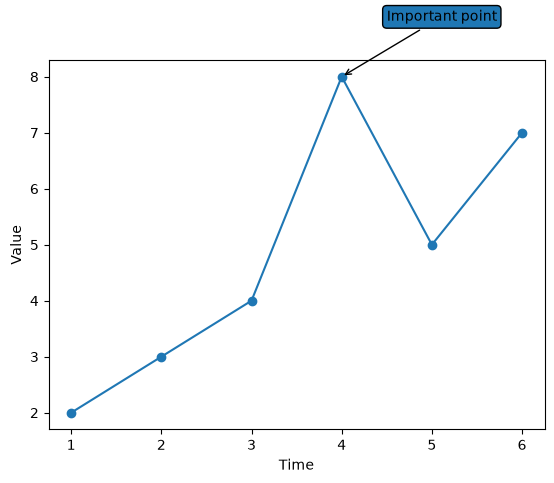

In [9]:
annotation_x = np.arange(1, 7)
annotation_y = [2, 3, 4, 8, 5, 7]

fig, ax = plt.subplots()

ax.plot(annotation_x, annotation_y, marker="o")

ax.annotate(
    "Important point",
    xy=(4, 8),
    xytext=(4.5, 9),
    arrowprops={"arrowstyle": "->"},
    bbox={"boxstyle": "round,pad=0.3"}
)

ax.set_xlabel("Time")
ax.set_ylabel("Value")

plt.show()

# 7. Reference Lines and Shaded Regions

Reference lines are useful for thresholds, baselines, and clinical cutoffs.

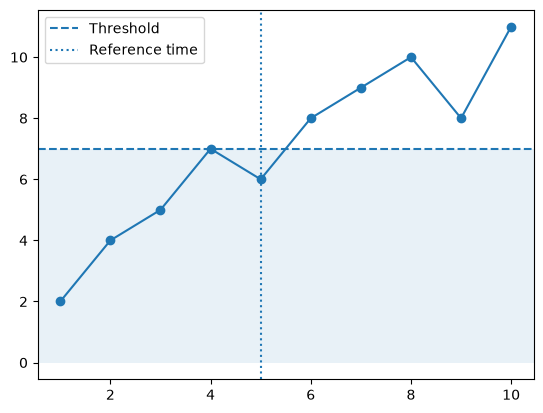

In [10]:
reference_x = np.arange(1, 11)
reference_y = [2, 4, 5, 7, 6, 8, 9, 10, 8, 11]

fig, ax = plt.subplots()

ax.plot(reference_x, reference_y, marker="o")
ax.axhline(7, linestyle="--", label="Threshold")
ax.axvline(5, linestyle=":", label="Reference time")
ax.axhspan(0, 7, alpha=0.1)

ax.legend()
plt.show()

# 8. Advanced Colors and Colormaps

Matplotlib supports named colors, hexadecimal colors, RGB/RGBA values, and colormaps.

For scientific visualization, color should communicate information rather than simply decorate a figure.

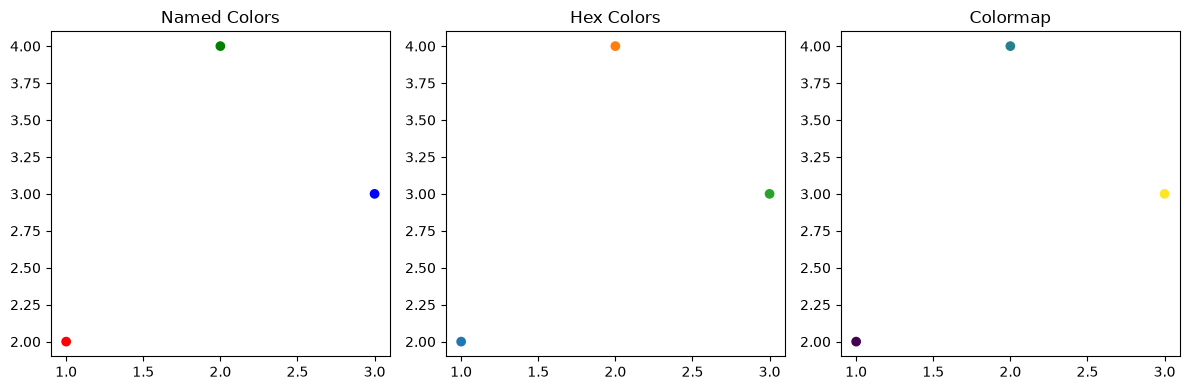

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter([1, 2, 3], [2, 4, 3], c=["red", "green", "blue"])
axes[0].set_title("Named Colors")

axes[1].scatter([1, 2, 3], [2, 4, 3], c=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Hex Colors")

axes[2].scatter(
    [1, 2, 3],
    [2, 4, 3],
    c=[0.2, 0.5, 0.9],
    cmap="viridis"
)
axes[2].set_title("Colormap")

plt.tight_layout()
plt.show()

## Sequential, Diverging, and Qualitative Colormaps

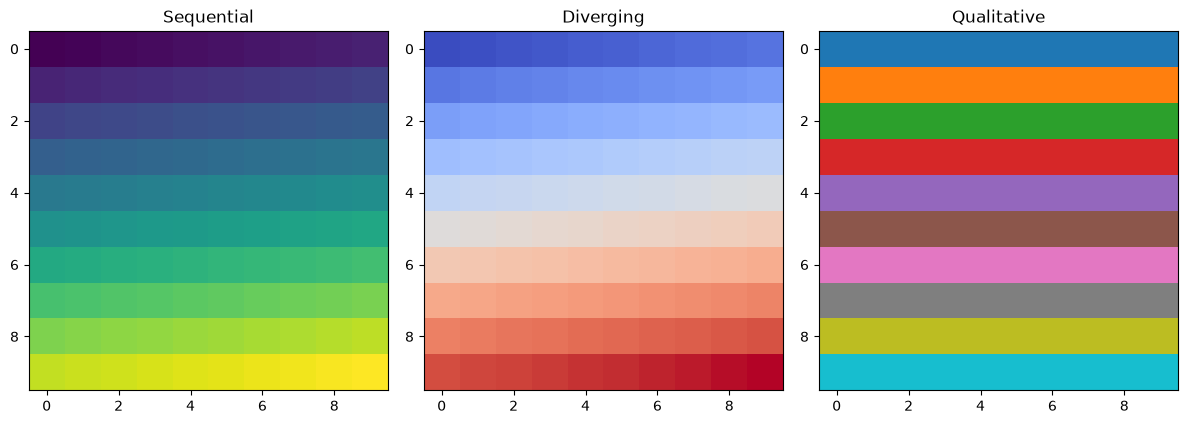

In [12]:
color_values = np.linspace(0, 1, 100).reshape(10, 10)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(color_values, cmap="viridis")
axes[0].set_title("Sequential")

axes[1].imshow(color_values, cmap="coolwarm")
axes[1].set_title("Diverging")

axes[2].imshow(color_values, cmap="tab10")
axes[2].set_title("Qualitative")

plt.tight_layout()
plt.show()

# 9. Colorbars

A colorbar explains how numerical values map to colors.

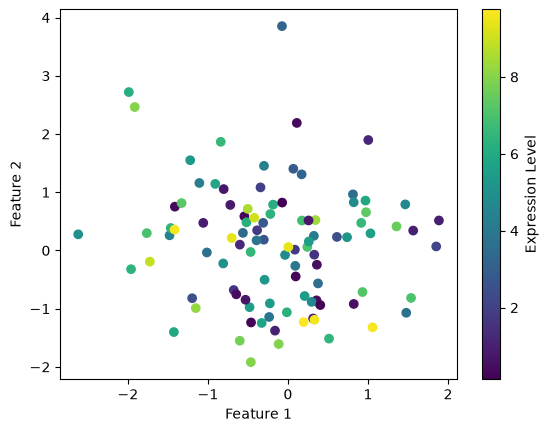

In [13]:
scatter_x = np.random.randn(100)
scatter_y = np.random.randn(100)
expression_values = np.random.uniform(0, 10, 100)

fig, ax = plt.subplots()

scatter = ax.scatter(
    scatter_x,
    scatter_y,
    c=expression_values,
    cmap="viridis"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Expression Level")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.show()

# 10. Normalization

Normalization controls how data values are mapped to colors.

Useful classes include `Normalize`, `LogNorm`, and `TwoSlopeNorm`.

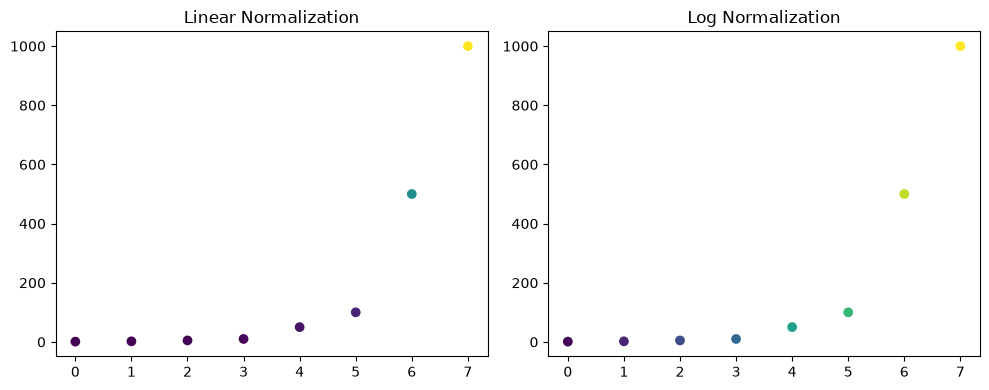

In [14]:
norm_values = np.array([1, 2, 5, 10, 50, 100, 500, 1000])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(
    np.arange(len(norm_values)),
    norm_values,
    c=norm_values,
    norm=Normalize(),
    cmap="viridis"
)
axes[0].set_title("Linear Normalization")

axes[1].scatter(
    np.arange(len(norm_values)),
    norm_values,
    c=norm_values,
    norm=LogNorm(vmin=1, vmax=1000),
    cmap="viridis"
)
axes[1].set_title("Log Normalization")

plt.tight_layout()
plt.show()

# 11. Advanced Scatter Plots

A scatter plot can encode multiple variables using position, color, size, and transparency.

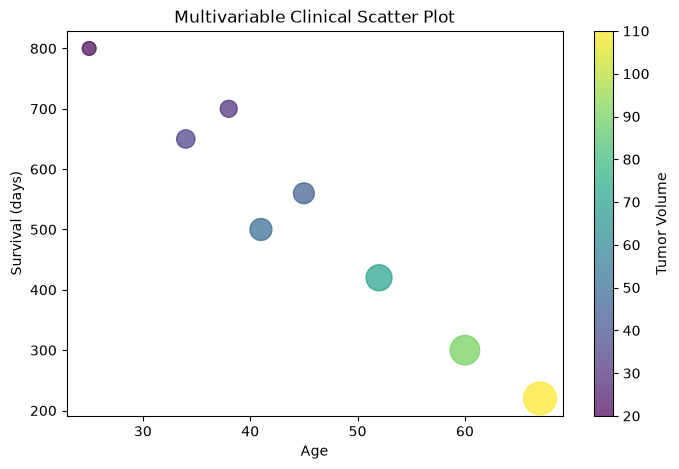

In [15]:
age_values = np.array([25, 34, 41, 52, 60, 67, 45, 38])
survival_values = np.array([800, 650, 500, 420, 300, 220, 560, 700])
tumor_volume_values = np.array([20, 35, 50, 70, 90, 110, 45, 30])

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    age_values,
    survival_values,
    s=tumor_volume_values * 5,
    c=tumor_volume_values,
    cmap="viridis",
    alpha=0.7
)

fig.colorbar(scatter, ax=ax, label="Tumor Volume")

ax.set_xlabel("Age")
ax.set_ylabel("Survival (days)")
ax.set_title("Multivariable Clinical Scatter Plot")

plt.show()

# 12. Boxplots

Boxplots summarize distributions using quartiles, median, whiskers, and potential outliers.

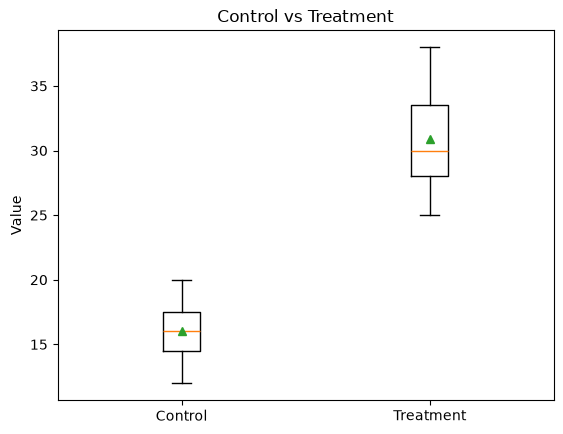

In [17]:
control_values = [12, 15, 14, 18, 20, 17, 16]
treatment_values = [25, 27, 29, 30, 32, 35, 38]

fig, ax = plt.subplots()

ax.boxplot(
    [control_values, treatment_values],
    tick_labels=["Control", "Treatment"],
    showmeans=True
)

ax.set_ylabel("Value")
ax.set_title("Control vs Treatment")

plt.show()

# 13. Violin Plots

Violin plots show the distribution shape in addition to summary statistics.

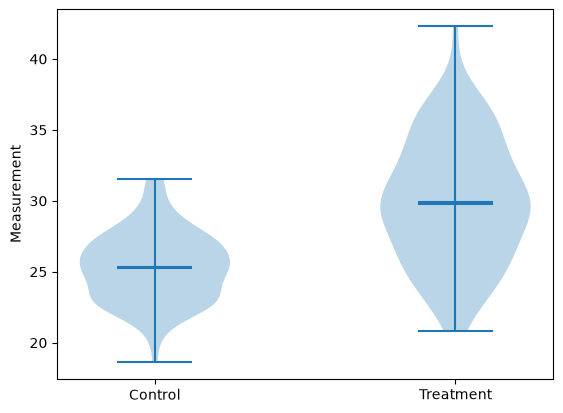

In [18]:
violin_control = np.random.normal(25, 3, 100)
violin_treatment = np.random.normal(30, 4, 100)

fig, ax = plt.subplots()

ax.violinplot(
    [violin_control, violin_treatment],
    showmeans=True,
    showmedians=True
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Control", "Treatment"])
ax.set_ylabel("Measurement")

plt.show()

# 14. Error Bars

Error bars can represent standard deviation, standard error, confidence intervals, or another uncertainty measure.

Always state what the error represents.

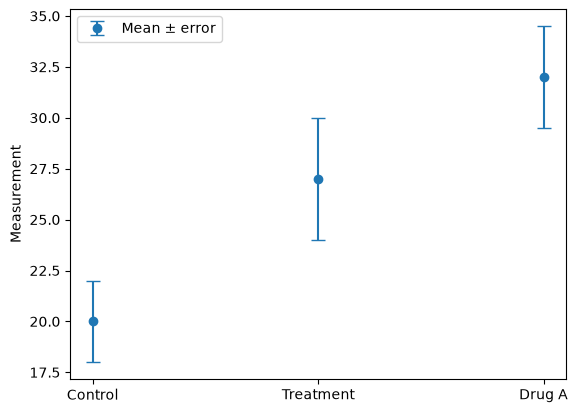

In [19]:
group_names = ["Control", "Treatment", "Drug A"]
group_means = [20, 27, 32]
group_errors = [2, 3, 2.5]

fig, ax = plt.subplots()

ax.errorbar(
    group_names,
    group_means,
    yerr=group_errors,
    fmt="o",
    capsize=5,
    label="Mean ± error"
)

ax.set_ylabel("Measurement")
ax.legend()

plt.show()

# 15. Heatmaps with imshow()

`imshow()` can display matrix-like data such as gene expression and correlation matrices.

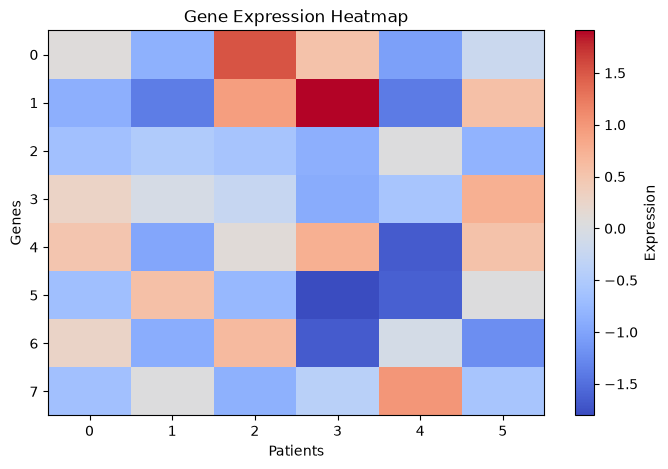

In [20]:
expression_matrix = np.random.normal(0, 1, (8, 6))

fig, ax = plt.subplots(figsize=(8, 5))

heatmap = ax.imshow(
    expression_matrix,
    cmap="coolwarm",
    aspect="auto"
)

fig.colorbar(heatmap, ax=ax, label="Expression")

ax.set_xlabel("Patients")
ax.set_ylabel("Genes")
ax.set_title("Gene Expression Heatmap")

plt.show()

## Annotated Heatmap

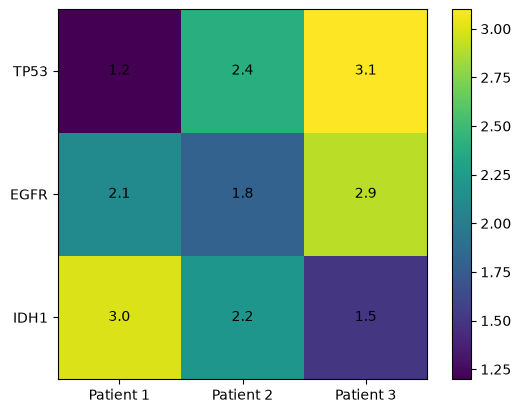

In [21]:
annotated_matrix = np.array([
    [1.2, 2.4, 3.1],
    [2.1, 1.8, 2.9],
    [3.0, 2.2, 1.5]
])

fig, ax = plt.subplots()

image = ax.imshow(annotated_matrix, cmap="viridis")

fig.colorbar(image, ax=ax)

for row in range(annotated_matrix.shape[0]):
    for col in range(annotated_matrix.shape[1]):
        ax.text(
            col,
            row,
            f"{annotated_matrix[row, col]:.1f}",
            ha="center",
            va="center"
        )

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Patient 1", "Patient 2", "Patient 3"])
ax.set_yticklabels(["TP53", "EGFR", "IDH1"])

plt.show()

# 16. Contour Plots

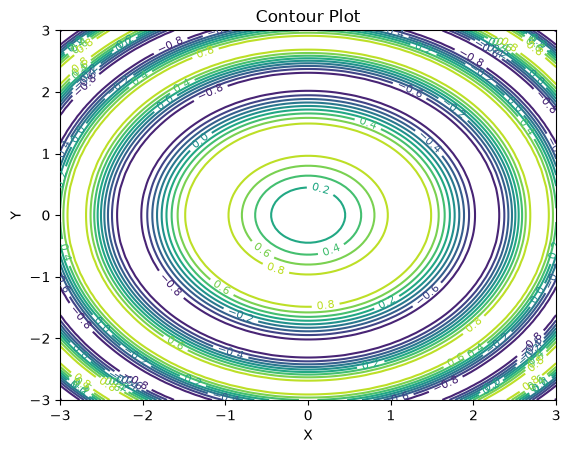

In [22]:
contour_x = np.linspace(-3, 3, 100)
contour_y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(contour_x, contour_y)
Z = np.sin(X**2 + Y**2)

fig, ax = plt.subplots()

contours = ax.contour(X, Y, Z, levels=10)
ax.clabel(contours, inline=True, fontsize=8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Contour Plot")

plt.show()

## Filled Contours

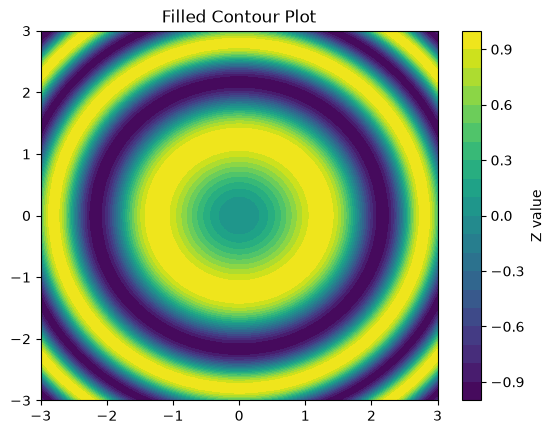

In [23]:
fig, ax = plt.subplots()

filled = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
fig.colorbar(filled, ax=ax, label="Z value")

ax.set_title("Filled Contour Plot")

plt.show()

# 17. 3D Visualization

Matplotlib supports basic 3D scientific visualization.

Use 3D only when the third dimension adds meaningful information.

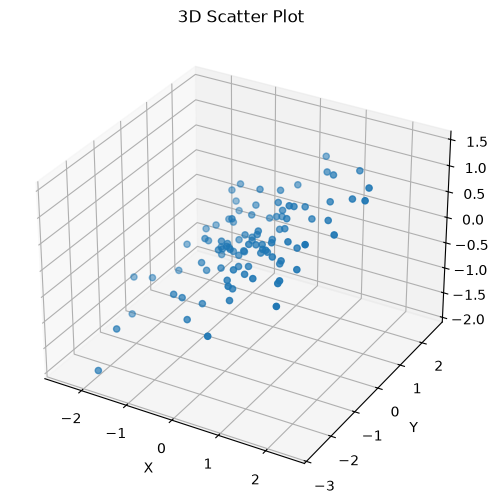

In [24]:
x_3d = np.random.randn(100)
y_3d = np.random.randn(100)
z_3d = x_3d * 0.5 + y_3d * 0.3 + np.random.randn(100) * 0.2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_3d, y_3d, z_3d)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Scatter Plot")

plt.show()

## 3D Surface Plot

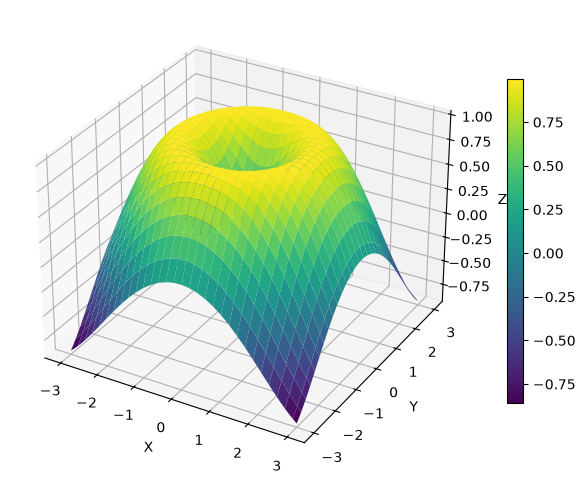

In [25]:
surface_x = np.linspace(-3, 3, 60)
surface_y = np.linspace(-3, 3, 60)

X_surface, Y_surface = np.meshgrid(surface_x, surface_y)
Z_surface = np.sin(np.sqrt(X_surface**2 + Y_surface**2))

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X_surface,
    Y_surface,
    Z_surface,
    cmap="viridis"
)

fig.colorbar(surface, ax=ax, shrink=0.7)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

# 18. Image Visualization

`imshow()` can display arrays as images. Grayscale visualization is common for medical imaging.

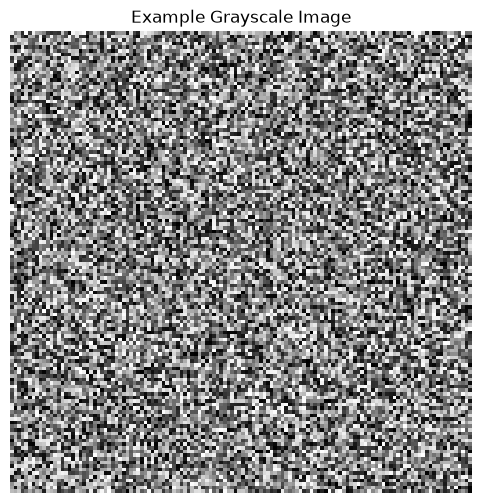

In [26]:
mri_like_image = np.random.rand(128, 128)

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(mri_like_image, cmap="gray")
ax.set_title("Example Grayscale Image")
ax.axis("off")

plt.show()

## Image + Segmentation Mask Overlay

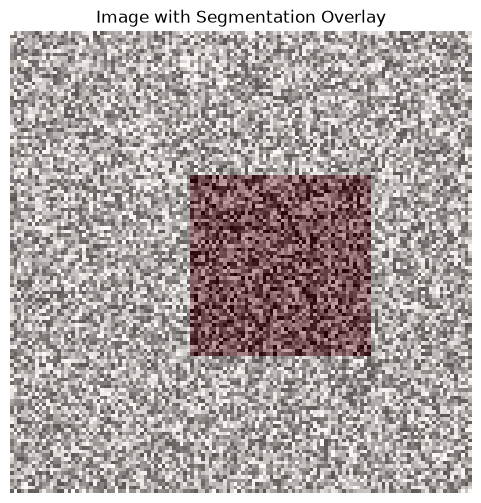

In [27]:
mri_image = np.random.rand(128, 128)

mask = np.zeros((128, 128))
mask[40:90, 50:100] = 1

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(mri_image, cmap="gray")
ax.imshow(mask, alpha=0.35, cmap="Reds")

ax.set_title("Image with Segmentation Overlay")
ax.axis("off")

plt.show()

## Multiple MRI Slices

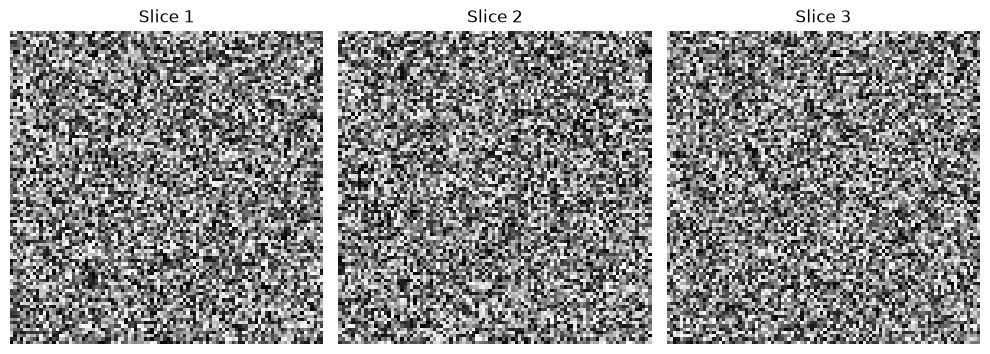

In [28]:
slice_stack = np.random.rand(3, 96, 96)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for index, ax in enumerate(axes):
    ax.imshow(slice_stack[index], cmap="gray")
    ax.set_title(f"Slice {index + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 19. Date and Time Visualization

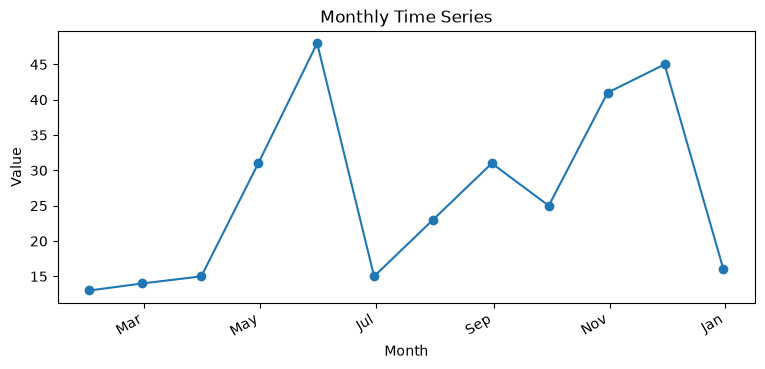

In [29]:
import matplotlib.dates as mdates

date_values = pd.date_range("2026-01-01", periods=12, freq="ME")
time_series_values = np.random.randint(10, 50, 12)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(date_values, time_series_values, marker="o")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_xlabel("Month")
ax.set_ylabel("Value")
ax.set_title("Monthly Time Series")

fig.autofmt_xdate()
plt.show()

# 20. Figure-Level Text

`fig.text()` places text relative to the whole Figure. It is useful for panel labels such as `(A)`, `(B)`, and `(C)`.

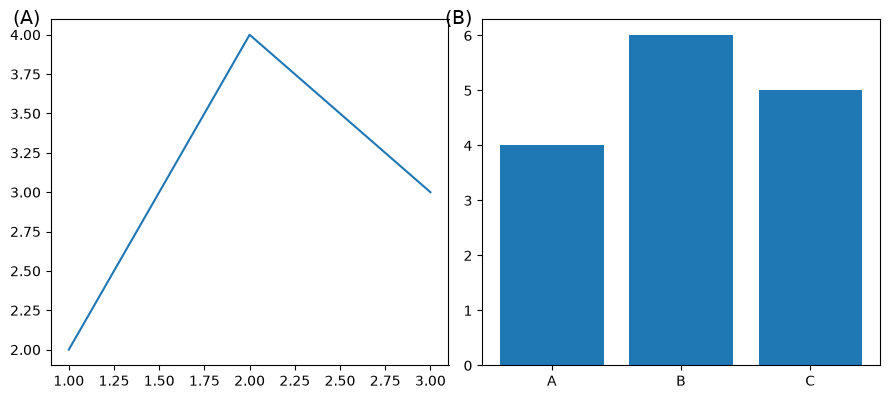

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].plot([1, 2, 3], [2, 4, 3])
axes[1].bar(["A", "B", "C"], [4, 6, 5])

fig.text(0.02, 0.95, "(A)", fontsize=14)
fig.text(0.50, 0.95, "(B)", fontsize=14)

plt.tight_layout()
plt.show()

# 21. Layout Management

Important tools:

- `tight_layout()`
- `subplots_adjust()`
- `constrained_layout=True`

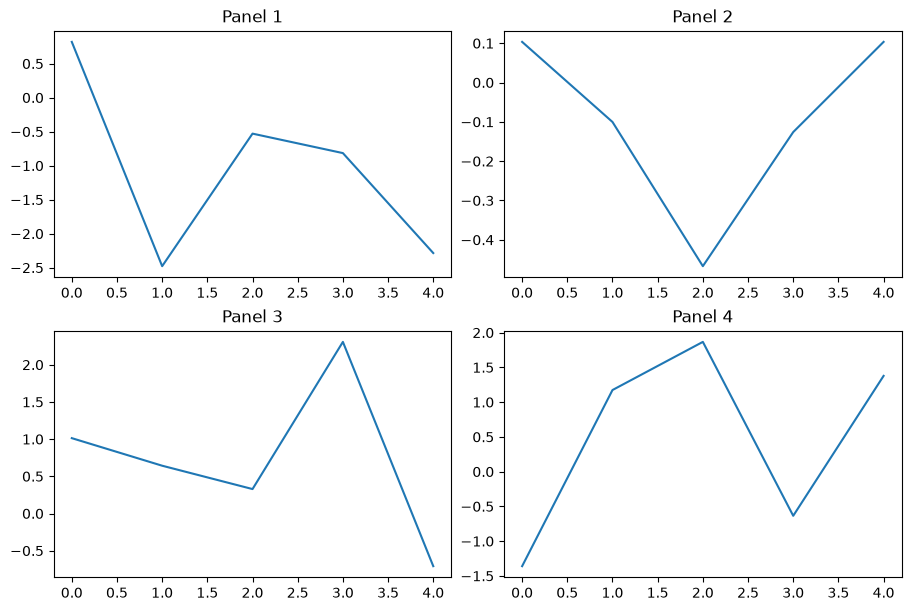

In [31]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 6),
    constrained_layout=True
)

for index, ax in enumerate(axes.flat):
    ax.plot(np.arange(5), np.random.randn(5))
    ax.set_title(f"Panel {index + 1}")

plt.show()

## Manual Spacing

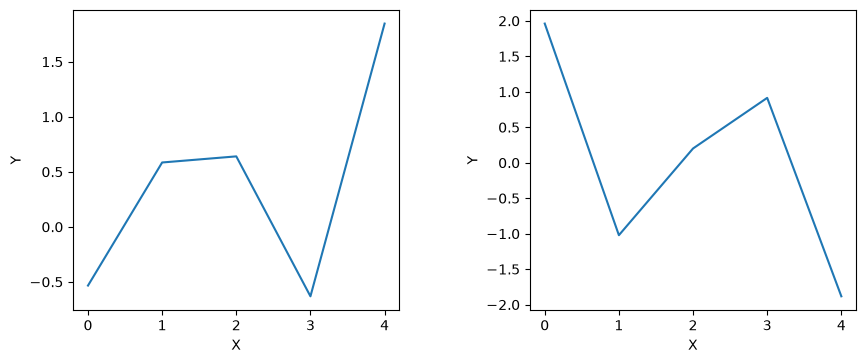

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax in axes:
    ax.plot(np.arange(5), np.random.randn(5))
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.15,
    top=0.9,
    wspace=0.4
)

plt.show()

# 22. Scientific Notation and Axis Formatting

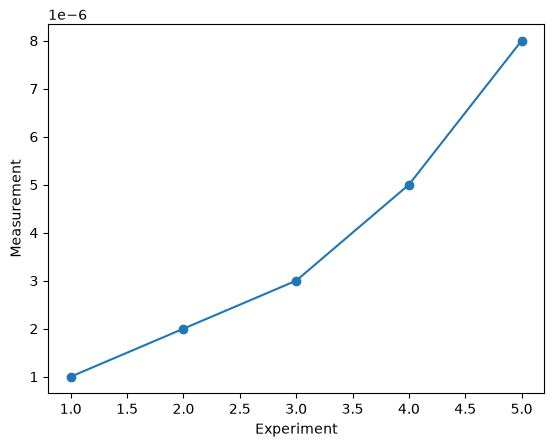

In [33]:
notation_x = np.arange(1, 6)
notation_y = np.array([1e-6, 2e-6, 3e-6, 5e-6, 8e-6])

fig, ax = plt.subplots()

ax.plot(notation_x, notation_y, marker="o")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax.set_xlabel("Experiment")
ax.set_ylabel("Measurement")

plt.show()

# 23. zorder

`zorder` controls the drawing order. Higher values appear on top.

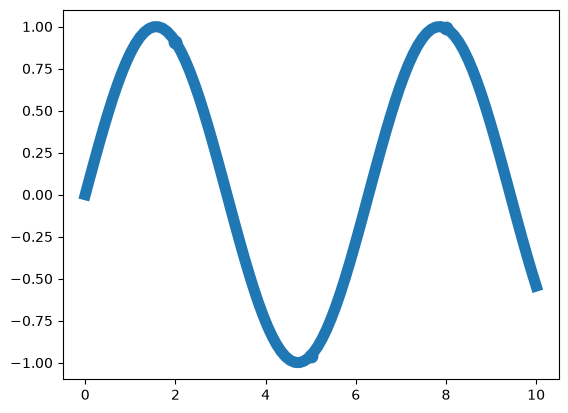

In [34]:
zorder_x = np.linspace(0, 10, 100)
zorder_y = np.sin(zorder_x)

fig, ax = plt.subplots()

ax.plot(zorder_x, zorder_y, linewidth=8, zorder=1)
ax.scatter(
    [2, 5, 8],
    np.sin([2, 5, 8]),
    s=80,
    zorder=3
)

plt.show()

# 24. Matplotlib + Pandas

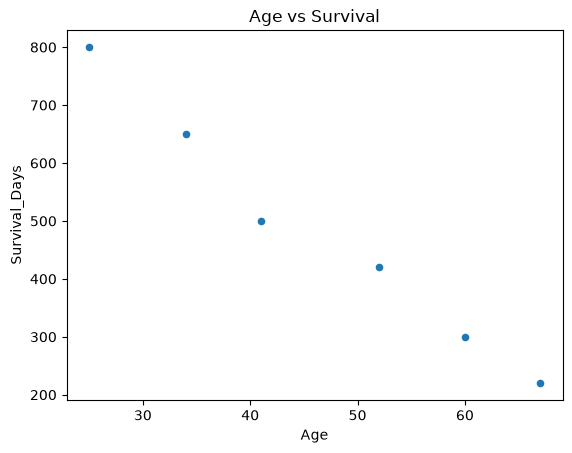

In [35]:
clinical = pd.DataFrame({
    "Age": [25, 34, 41, 52, 60, 67],
    "Survival_Days": [800, 650, 500, 420, 300, 220],
    "Treatment": ["A", "A", "B", "B", "A", "B"]
})

clinical.plot(
    x="Age",
    y="Survival_Days",
    kind="scatter",
    title="Age vs Survival"
)

plt.show()

## Grouped Pandas Visualization

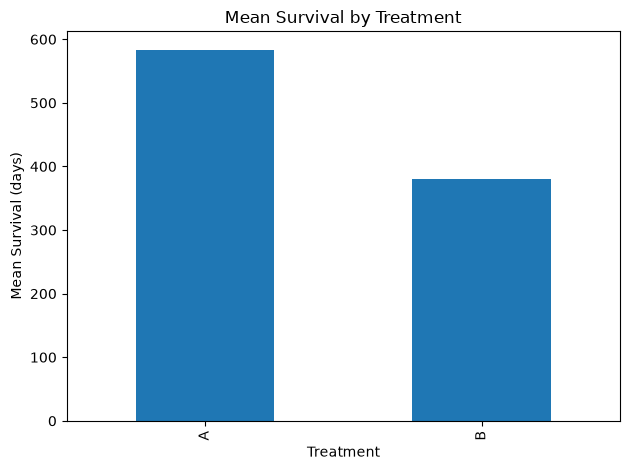

In [36]:
treatment_summary = clinical.groupby("Treatment")["Survival_Days"].mean()

treatment_summary.plot(
    kind="bar",
    title="Mean Survival by Treatment",
    ylabel="Mean Survival (days)"
)

plt.tight_layout()
plt.show()

# 25. Matplotlib + NumPy

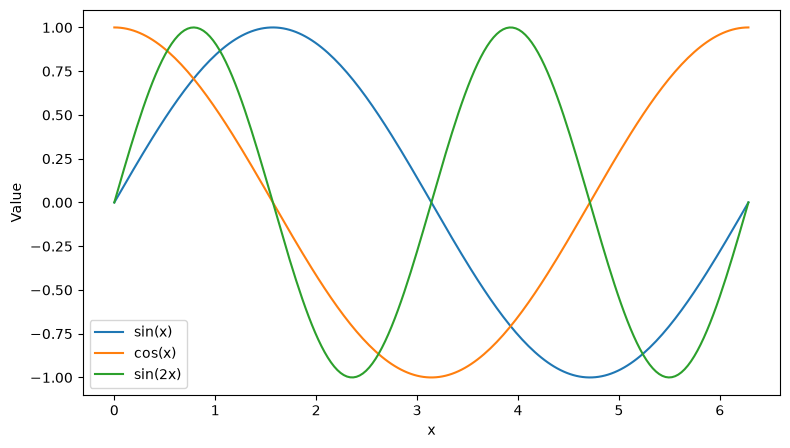

In [37]:
function_x = np.linspace(0, 2 * np.pi, 200)

functions = {
    "sin(x)": np.sin(function_x),
    "cos(x)": np.cos(function_x),
    "sin(2x)": np.sin(2 * function_x)
}

fig, ax = plt.subplots(figsize=(9, 5))

for label, values in functions.items():
    ax.plot(function_x, values, label=label)

ax.set_xlabel("x")
ax.set_ylabel("Value")
ax.legend()

plt.show()

# 26. Bioinformatics Visualization — Gene Expression

Gene expression is often represented as:

**Rows = genes**

**Columns = patients or samples**

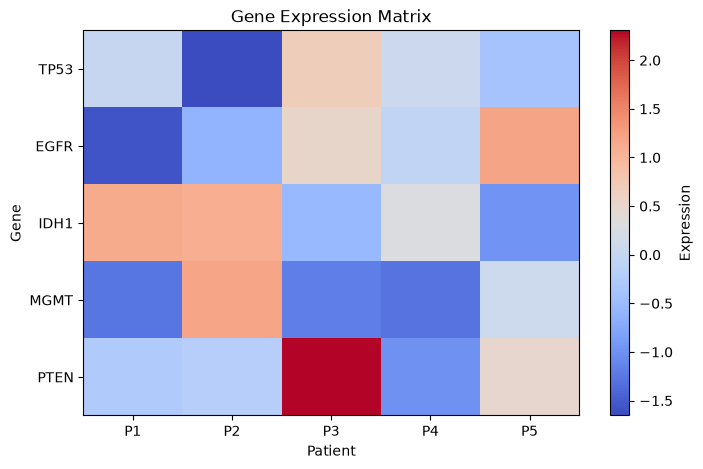

In [38]:
gene_names = ["TP53", "EGFR", "IDH1", "MGMT", "PTEN"]
patient_names = ["P1", "P2", "P3", "P4", "P5"]

gene_expression = np.random.normal(
    loc=0,
    scale=1,
    size=(len(gene_names), len(patient_names))
)

fig, ax = plt.subplots(figsize=(8, 5))

expression_image = ax.imshow(
    gene_expression,
    cmap="coolwarm",
    aspect="auto"
)

fig.colorbar(expression_image, ax=ax, label="Expression")

ax.set_xticks(range(len(patient_names)))
ax.set_xticklabels(patient_names)

ax.set_yticks(range(len(gene_names)))
ax.set_yticklabels(gene_names)

ax.set_xlabel("Patient")
ax.set_ylabel("Gene")
ax.set_title("Gene Expression Matrix")

plt.show()

# 27. Mutation Frequency Visualization

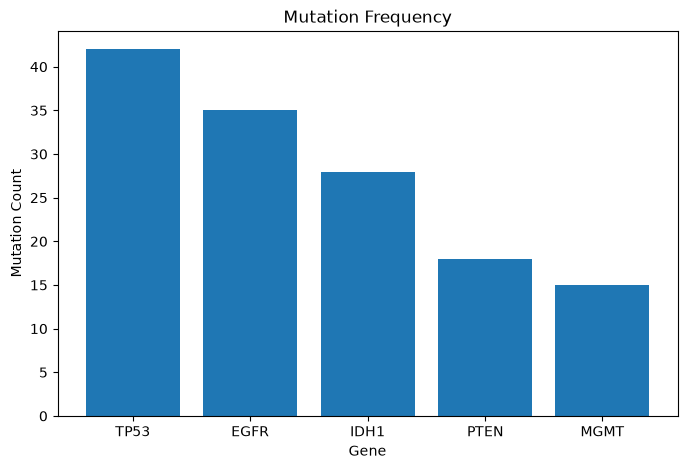

In [39]:
mutation_genes = ["TP53", "EGFR", "IDH1", "PTEN", "MGMT"]
mutation_counts = [42, 35, 28, 18, 15]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(mutation_genes, mutation_counts)

ax.set_xlabel("Gene")
ax.set_ylabel("Mutation Count")
ax.set_title("Mutation Frequency")

plt.show()

# 28. Clinical Correlation Matrix

Correlation is useful for exploratory analysis.

> Correlation does not establish causation.

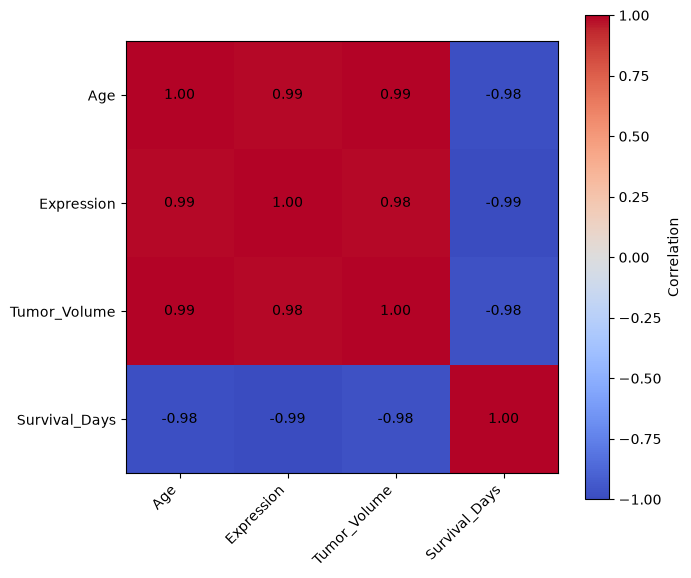

In [40]:
clinical_numeric = pd.DataFrame({
    "Age": [25, 34, 41, 52, 60, 67, 45, 38],
    "Expression": [2.1, 3.5, 4.0, 5.2, 6.1, 7.0, 4.7, 3.2],
    "Tumor_Volume": [20, 35, 45, 70, 90, 110, 55, 40],
    "Survival_Days": [800, 650, 540, 420, 300, 220, 500, 700]
})

correlation = clinical_numeric.corr()

fig, ax = plt.subplots(figsize=(7, 6))

correlation_image = ax.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

fig.colorbar(correlation_image, ax=ax, label="Correlation")

correlation_labels = correlation.columns

ax.set_xticks(range(len(correlation_labels)))
ax.set_xticklabels(correlation_labels, rotation=45, ha="right")

ax.set_yticks(range(len(correlation_labels)))
ax.set_yticklabels(correlation_labels)

for row in range(len(correlation_labels)):
    for col in range(len(correlation_labels)):
        ax.text(
            col,
            row,
            f"{correlation.iloc[row, col]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# 29. Survival-Style Visualization

A simple plot can distinguish observed events from censored observations.

For real survival analysis, use appropriate survival-analysis methods such as Kaplan–Meier estimation rather than treating censored survival data as ordinary regression data.

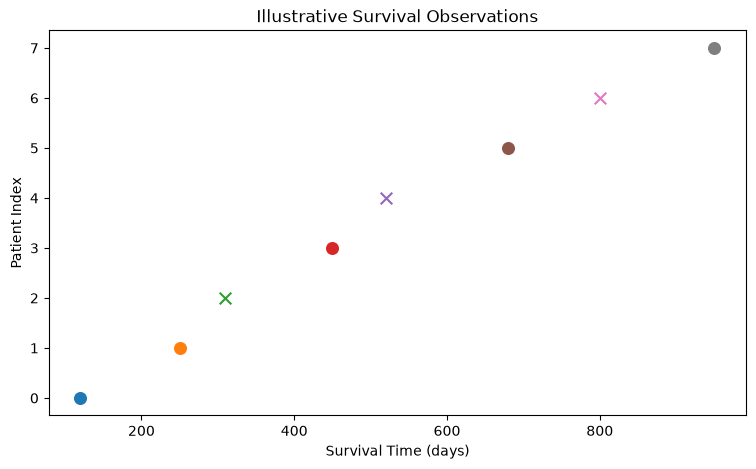

In [41]:
survival_days = np.array([120, 250, 310, 450, 520, 680, 800, 950])
event_status = np.array([1, 1, 0, 1, 0, 1, 0, 1])

fig, ax = plt.subplots(figsize=(9, 5))

for index, (time_value, event_value) in enumerate(
    zip(survival_days, event_status)
):
    ax.scatter(
        time_value,
        index,
        marker="o" if event_value == 1 else "x",
        s=70
    )

ax.set_xlabel("Survival Time (days)")
ax.set_ylabel("Patient Index")
ax.set_title("Illustrative Survival Observations")

plt.show()

# 30. Model Training Curves

Training and validation curves are common in Machine Learning and Deep Learning.

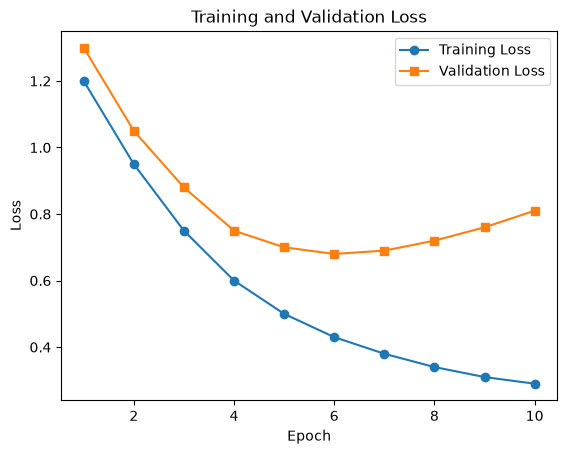

In [42]:
epochs = np.arange(1, 11)

train_loss = [1.20, 0.95, 0.75, 0.60, 0.50, 0.43, 0.38, 0.34, 0.31, 0.29]
validation_loss = [1.30, 1.05, 0.88, 0.75, 0.70, 0.68, 0.69, 0.72, 0.76, 0.81]

fig, ax = plt.subplots()

ax.plot(epochs, train_loss, marker="o", label="Training Loss")
ax.plot(epochs, validation_loss, marker="s", label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()

plt.show()

# 31. Publication-Quality Figures

For research figures, pay attention to:

- Figure dimensions
- Font sizes
- Line widths
- Marker sizes
- Axis labels
- Legend placement
- White space
- Export format
- DPI

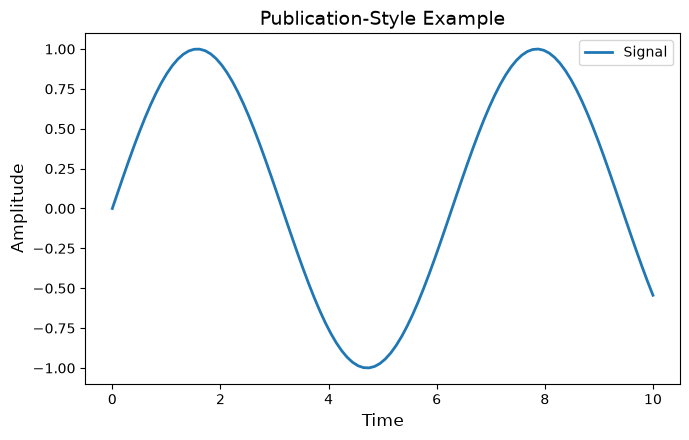

In [43]:
publication_x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    publication_x,
    np.sin(publication_x),
    linewidth=2,
    label="Signal"
)

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_title("Publication-Style Example", fontsize=14)
ax.tick_params(axis="both", labelsize=10)
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()

## Saving Publication Figures

PNG is a raster format, while PDF and SVG can preserve vector graphics.

In [44]:
fig.savefig("publication_figure.png", dpi=300, bbox_inches="tight")
fig.savefig("publication_figure.pdf", bbox_inches="tight")
fig.savefig("publication_figure.svg", bbox_inches="tight")

# 32. Scientific Figure Design

Good scientific visualization should:

- Match the plot type to the data
- Use clear labels and units
- Represent uncertainty honestly
- Keep comparable panels consistent
- Avoid unnecessary decoration
- Avoid misleading scales
- Use color intentionally
- Remain readable at the final publication size

# 33. Mini Project 1 — Clinical Data Dashboard

Create a 2×2 figure containing:

1. Age distribution
2. Survival distribution
3. Age vs survival
4. Treatment comparison

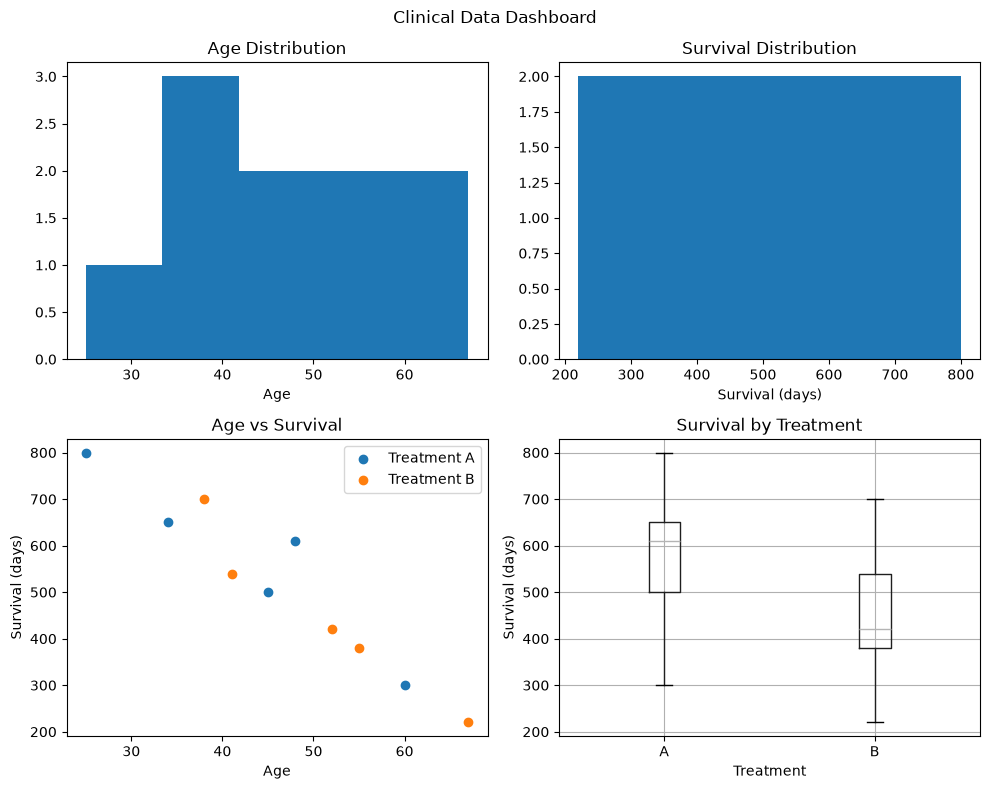

In [45]:
clinical_project = pd.DataFrame({
    "Age": [25, 34, 41, 52, 60, 67, 45, 38, 55, 48],
    "Survival_Days": [800, 650, 540, 420, 300, 220, 500, 700, 380, 610],
    "Treatment": ["A", "A", "B", "B", "A", "B", "A", "B", "B", "A"]
})

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(clinical_project["Age"], bins=5)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")

axes[0, 1].hist(clinical_project["Survival_Days"], bins=5)
axes[0, 1].set_title("Survival Distribution")
axes[0, 1].set_xlabel("Survival (days)")

for group_name, group_data in clinical_project.groupby("Treatment"):
    axes[1, 0].scatter(
        group_data["Age"],
        group_data["Survival_Days"],
        label=f"Treatment {group_name}"
    )

axes[1, 0].set_title("Age vs Survival")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Survival (days)")
axes[1, 0].legend()

clinical_project.boxplot(
    column="Survival_Days",
    by="Treatment",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Survival by Treatment")
axes[1, 1].set_xlabel("Treatment")
axes[1, 1].set_ylabel("Survival (days)")

fig.suptitle("Clinical Data Dashboard")
plt.tight_layout()
plt.show()

# 34. Mini Project 2 — Gene Expression Analysis

Build a figure containing:

- Gene expression heatmap
- Mean expression per gene
- Expression distribution

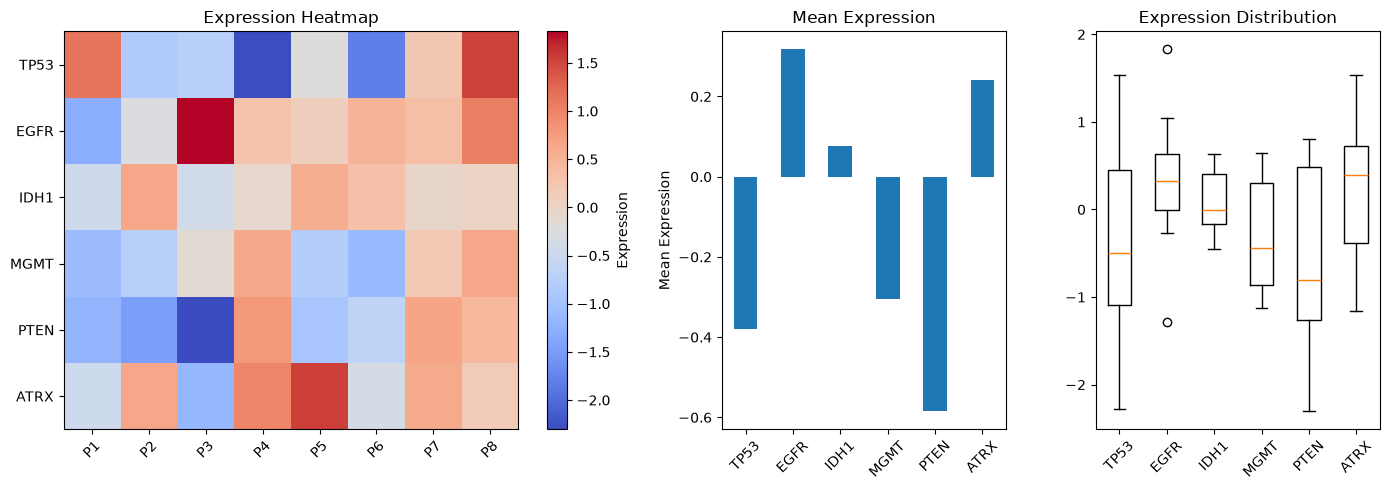

In [47]:
project_genes = ["TP53", "EGFR", "IDH1", "MGMT", "PTEN", "ATRX"]
project_samples = [f"P{i}" for i in range(1, 9)]

project_expression = pd.DataFrame(
    np.random.normal(
        0,
        1,
        (len(project_samples), len(project_genes))
    ),
    index=project_samples,
    columns=project_genes
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2, 1, 1]}
)
image = axes[0].imshow(
    project_expression.T,
    cmap="coolwarm",
    aspect="auto"
)

fig.colorbar(
    image,
    ax=axes[0],
    label="Expression"
)

axes[0].set_xticks(range(len(project_samples)))
axes[0].set_xticklabels(project_samples, rotation=45)

axes[0].set_yticks(range(len(project_genes)))
axes[0].set_yticklabels(project_genes)

axes[0].set_title("Expression Heatmap")

project_expression.mean().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Mean Expression")
axes[1].set_ylabel("Mean Expression")
axes[1].tick_params(axis="x", rotation=45)

axes[2].boxplot(
    [project_expression[gene] for gene in project_genes],
    tick_labels=project_genes
)

axes[2].set_title("Expression Distribution")
axes[2].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

# 35. Mini Project 3 — MRI Slice and Segmentation

This project demonstrates:

**Image → Mask → Overlay**

The arrays are synthetic and are used only for learning.

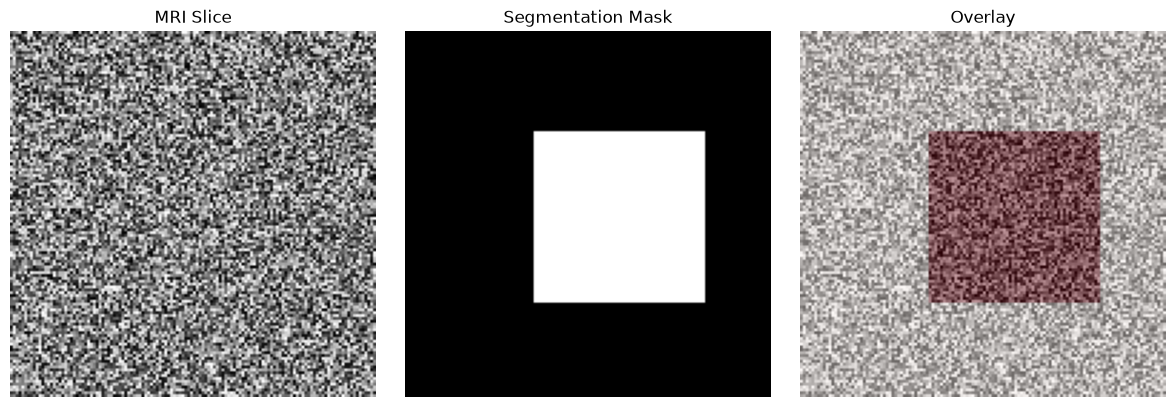

In [48]:
image_data = np.random.rand(128, 128)

mask_data = np.zeros((128, 128))
mask_data[35:95, 45:105] = 1

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image_data, cmap="gray")
axes[0].set_title("MRI Slice")
axes[0].axis("off")

axes[1].imshow(mask_data, cmap="gray")
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

axes[2].imshow(image_data, cmap="gray")
axes[2].imshow(mask_data, alpha=0.4, cmap="Reds")
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 36. Exercises

Try solving these without looking at previous cells.

### Exercise 1
Create a 2×2 GridSpec figure with one large plot and three smaller plots.

### Exercise 2
Create a scatter plot where:
- x = Age
- y = Survival
- color = Tumor Volume
- size = Tumor Volume

### Exercise 3
Create a heatmap for a 10×8 gene expression matrix.

### Exercise 4
Create a boxplot comparing three treatment groups.

### Exercise 5
Create an MRI-style image and overlay a binary segmentation mask.

### Exercise 6
Create training and validation loss curves and annotate the epoch with the lowest validation loss.

### Exercise 7
Create a publication-style multi-panel figure and save it as both PNG and PDF.

# 37. Common Mistakes

### 1. Different x and y lengths

The x and y arrays must contain compatible numbers of observations.

### 2. Reusing notebook variables

A generic variable such as `x`, `y`, or `data` may contain values from an earlier cell.

### 3. Choosing the wrong plot

- Line → ordered trends
- Scatter → relationships
- Bar → category comparisons
- Histogram → distributions
- Boxplot → distribution summaries
- Heatmap → matrix-like data

### 4. Misleading axes

Always inspect axis limits and scales.

### 5. Too much decoration

Scientific figures should communicate information clearly.

# 38. Matplotlib Function Map

## Figure and Layout
- `plt.figure()`
- `plt.subplots()`
- `fig.add_axes()`
- `fig.add_subplot()`
- `GridSpec`
- `tight_layout()`
- `constrained_layout`
- `subplots_adjust()`

## Plot Types
- `plot()`
- `scatter()`
- `bar()`
- `barh()`
- `hist()`
- `pie()`
- `stackplot()`
- `fill_between()`
- `boxplot()`
- `violinplot()`
- `errorbar()`
- `contour()`
- `contourf()`
- `imshow()`

## Advanced Controls
- `twinx()`
- `twiny()`
- `annotate()`
- `axhline()`
- `axvline()`
- `axhspan()`
- `axvspan()`
- `colorbar()`

## Output
- `savefig()`

# 39. Golden Rules

- **Match the visualization to the data.**
- **Keep x and y arrays compatible.**
- **Avoid accidental variable reuse in notebooks.**
- **Use labels and units.**
- **Explain uncertainty.**
- **Use color intentionally.**
- **Do not overuse 3D plots.**
- **Keep comparable panels consistent.**
- **Use GridSpec for complex layouts.**
- **Use vector formats when appropriate.**
- **Check the final figure at its intended size.**
- **For medical images, distinguish the original image, mask/prediction, and overlay.**

# 40. Part 1 vs Part 2

## Part 1 — Foundations

You learned:

- Common plot types
- Titles and labels
- Legends and grids
- Axes and ticks
- Subplots
- Object-Oriented Matplotlib
- Basic saving
- NumPy and Pandas integration

## Part 2 — Advanced Visualization

You learned:

- Complex figure layouts
- GridSpec
- Twin axes
- Custom legends
- Advanced annotations
- Colorbars and normalization
- Heatmaps
- Contour plots
- 3D visualization
- Image and segmentation visualization
- Statistical distributions
- Scientific figure design
- Publication-quality export
- Bioinformatics and Cancer AI visualization